# WiDS 2026 Datathon - Wildfire Hit Prediction

Predict the probability that a wildfire will hit critical infrastructure within 12, 24, 48, and 72 hours.

## Notebook Structure
1. Setup & Data Loading
2. Target Engineering
3. Feature Selection & Quality Audit
4. EDA (Correlation & Redundancy)
5. Feature Pruning Experiments
6. Model Definitions & Train/Val Split
7. Model Comparison
8. Feature Importance Analysis
9. Error Analysis
10. Final Predictions & Submission

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/sample_submission.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/train.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/metaData.csv
/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/test.csv


In [2]:
import glob

# Auto-detect data path (handles different Kaggle mount points)
train_candidates = glob.glob("/kaggle/input/**/train.csv", recursive=True)
test_candidates = glob.glob("/kaggle/input/**/test.csv", recursive=True)

if train_candidates and test_candidates:
    train_path = train_candidates[0]
    test_path = test_candidates[0]
else:
    # Fallback to known path
    train_path = "/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/train.csv"
    test_path = "/kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/test.csv"

print(f"Train path: {train_path}")
print(f"Test path: {test_path}")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train path: /kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/train.csv
Test path: /kaggle/input/competitions/WiDSWorldWide_GlobalDathon26/test.csv
Train shape: (221, 37)
Test shape: (95, 35)


## 2. Target Engineering

In [3]:
HORIZONS = [12, 24, 48, 72]
TARGET_COLS = [f"hit_by_{h}h" for h in HORIZONS]
NON_FEATURE_COLS = ["event_id", "event", "time_to_hit_hours"] + TARGET_COLS

for h in HORIZONS:
    hit_by_h = (train["event"] == 1) & (train["time_to_hit_hours"] <= h)
    train[f"hit_by_{h}h"] = hit_by_h.astype(int)

print("Positive label counts by horizon:")
for h in HORIZONS:
    col = f"hit_by_{h}h"
    print(f"  {col}: {train[col].sum()} / {len(train)}")

print(f"\nEvent distribution:\n{train['event'].value_counts()}")

Positive label counts by horizon:
  hit_by_12h: 49 / 221
  hit_by_24h: 63 / 221
  hit_by_48h: 66 / 221
  hit_by_72h: 69 / 221

Event distribution:
event
0    152
1     69
Name: count, dtype: int64


## 3. Feature Selection & Quality Audit

In [4]:
# Base features: everything except target/ID columns
X_base = train.drop(columns=NON_FEATURE_COLS).copy()
print("Base feature shape:", X_base.shape)
print("Features:", X_base.columns.tolist())

Base feature shape: (221, 34)
Features: ['num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth', 'log_area_ratio_0_5h', 'relative_growth_0_5h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'spread_bearing_deg', 'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h', 'dist_std_ci_0_5h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'closing_speed_m_per_h', 'closing_speed_abs_m_per_h', 'projected_advance_m', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h', 'alignment_cos', 'alignment_abs', 'cross_track_component', 'along_track_speed', 'event_start_hour', 'event_start_dayofweek', 'event_start_month']


In [5]:
def build_feature_quality_report(X_df, feature_set_name, near_constant_threshold=0.99):
    rows = []
    n_rows = len(X_df)

    for col in X_df.columns:
        s = X_df[col]
        missing_count = s.isna().sum()
        missing_pct = missing_count / n_rows
        non_null = s.dropna()
        n_unique = non_null.nunique()

        if len(non_null) == 0:
            top_value, top_freq_pct = np.nan, np.nan
        else:
            vc = non_null.value_counts(dropna=True)
            top_value = vc.index[0]
            top_freq_pct = vc.iloc[0] / len(non_null)

        is_constant = n_unique <= 1
        is_near_constant = (
            pd.notna(top_freq_pct)
            and top_freq_pct >= near_constant_threshold
            and not is_constant
        )

        flags = []
        if missing_pct >= 0.50:
            flags.append("high_missing")
        elif missing_pct >= 0.20:
            flags.append("medium_missing")
        if is_constant:
            flags.append("constant")
        elif is_near_constant:
            flags.append("near_constant")

        rows.append({
            "feature_set": feature_set_name,
            "feature": col,
            "dtype": str(s.dtype),
            "missing_pct": round(missing_pct, 3),
            "n_unique": n_unique,
            "top_value": top_value,
            "top_freq_pct": round(top_freq_pct, 3) if pd.notna(top_freq_pct) else np.nan,
            "quality_flag": ", ".join(flags) if flags else "ok",
        })

    return pd.DataFrame(rows)


feature_quality_df = build_feature_quality_report(X_base, "base")
print("Feature quality report:")
display(feature_quality_df.sort_values("top_freq_pct", ascending=False).head(15))

problems = feature_quality_df[feature_quality_df["quality_flag"] != "ok"]
print(f"\nProblematic features: {len(problems)}")
if len(problems):
    display(problems)

Feature quality report:


,feature_set,feature,dtype,missing_pct,n_unique,top_value,top_freq_pct,quality_flag
23,base,closing_speed_abs_m_per_h,float64,0.0,19,0.0,0.919,ok
22,base,closing_speed_m_per_h,float64,0.0,19,0.0,0.919,ok
24,base,projected_advance_m,float64,0.0,19,0.0,0.919,ok
20,base,dist_change_ci_0_5h,float64,0.0,19,0.0,0.919,ok
26,base,dist_fit_r2_0_5h,float64,0.0,20,0.0,0.914,ok
19,base,dist_std_ci_0_5h,float64,0.0,20,0.0,0.914,ok
8,base,log1p_growth,float64,0.0,25,0.0,0.891,ok
16,base,spread_bearing_sin,float64,0.0,26,0.0,0.887,ok
13,base,centroid_displacement_m,float64,0.0,26,0.0,0.887,ok
5,base,area_growth_rel_0_5h,float64,0.0,26,0.0,0.887,ok



Problematic features: 0


## 4. EDA - Correlation & Redundancy Analysis

Top 15 correlations with hit_by_48h:
dist_min_ci_0_5h               -0.466155
low_temporal_resolution_0_5h   -0.401975
num_perimeters_0_5h             0.387402
dt_first_last_0_5h              0.374137
alignment_abs                   0.369085
spread_bearing_cos             -0.336494
log1p_growth                    0.304991
spread_bearing_deg              0.293300
log_area_ratio_0_5h             0.238678
radial_growth_rate_m_per_h      0.223754
radial_growth_m                 0.218005
centroid_speed_m_per_h          0.217905
centroid_displacement_m         0.216616
spread_bearing_sin              0.196205
area_growth_rate_ha_per_h       0.179107
Name: hit_by_48h, dtype: float64


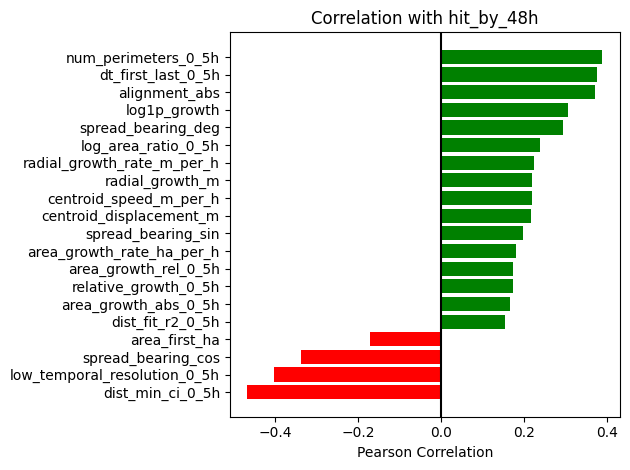

In [6]:
# Feature correlation with 48h target
H = 48
target_col = f"hit_by_{H}h"

df_corr = X_base.copy()
df_corr[target_col] = train[target_col].values
corr_series = df_corr.corr(numeric_only=True)[target_col].drop(target_col)
corr_sorted = corr_series.reindex(corr_series.abs().sort_values(ascending=False).index)

print(f"Top 15 correlations with {target_col}:")
print(corr_sorted.head(15))

# Bar plot
corr_top = corr_sorted.head(20).sort_values()
colors = ["green" if v > 0 else "red" for v in corr_top.values]
plt.barh(corr_top.index, corr_top.values, color=colors)
plt.axvline(0, color="black")
plt.title(f"Correlation with {target_col}")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()

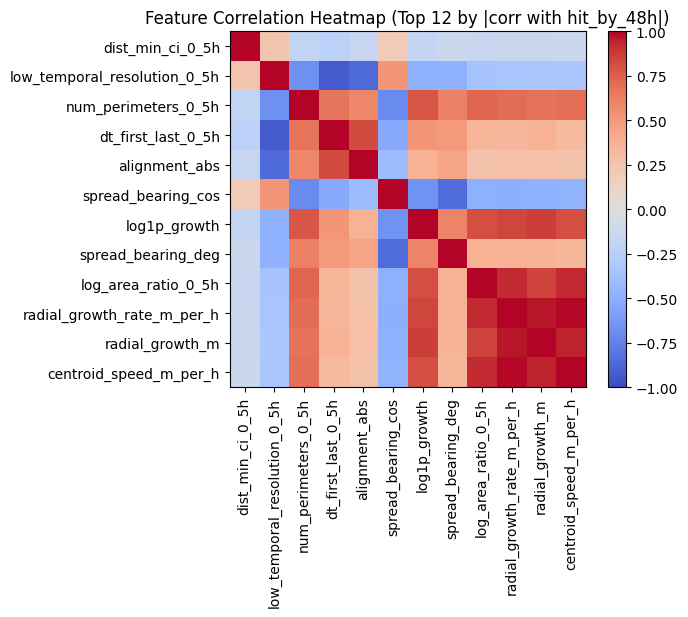

In [7]:
# Heatmap of top 12 features
top_features = corr_sorted.abs().head(12).index.tolist()
corr_matrix_top = X_base[top_features].corr()

plt.figure(figsize=(7, 6))
im = plt.imshow(corr_matrix_top, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im)
plt.title(f"Feature Correlation Heatmap (Top 12 by |corr with {target_col}|)")
plt.xticks(range(len(top_features)), top_features, rotation=90)
plt.yticks(range(len(top_features)), top_features)
plt.tight_layout()
plt.show()

Highly correlated pairs (|corr| > 0.85):
  low_temporal_resolution_0_5h  <->  dt_first_last_0_5h   corr = -0.924
  area_growth_rate_ha_per_h  <->  area_growth_abs_0_5h   corr = 0.991
  log_area_ratio_0_5h  <->  area_growth_rel_0_5h   corr = 0.886
  relative_growth_0_5h  <->  area_growth_rel_0_5h   corr = 1.000
  relative_growth_0_5h  <->  log_area_ratio_0_5h   corr = 0.886
  radial_growth_m  <->  area_growth_abs_0_5h   corr = 0.867
  radial_growth_m  <->  area_growth_rate_ha_per_h   corr = 0.913
  radial_growth_m  <->  log1p_growth   corr = 0.860
  radial_growth_rate_m_per_h  <->  log_area_ratio_0_5h   corr = 0.926
  radial_growth_rate_m_per_h  <->  radial_growth_m   corr = 0.966
  centroid_displacement_m  <->  area_growth_rate_ha_per_h   corr = 0.898
  centroid_displacement_m  <->  log_area_ratio_0_5h   corr = 0.855
  centroid_displacement_m  <->  radial_growth_m   corr = 0.989
  centroid_displacement_m  <->  radial_growth_rate_m_per_h   corr = 0.969
  centroid_speed_m_per_h  <->  log

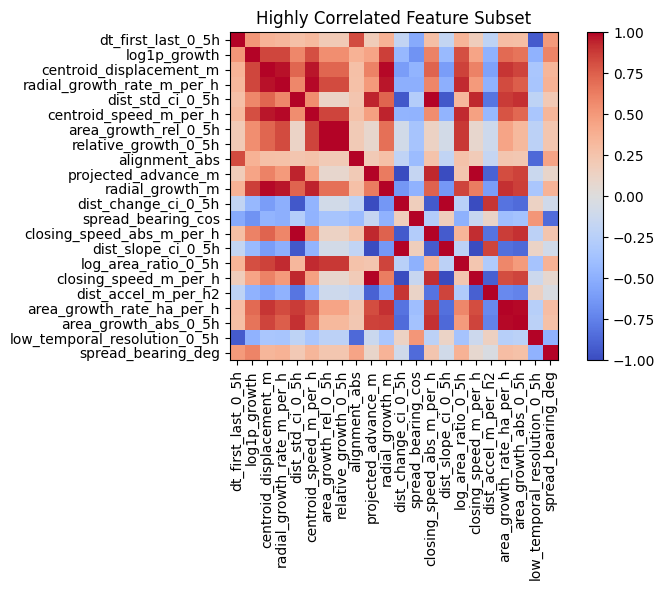

In [8]:
# Feature redundancy: find highly correlated pairs
corr_matrix = X_base.corr(numeric_only=True)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
threshold = 0.85

high_corr_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notnull(upper.loc[row, col]) and abs(upper.loc[row, col]) > threshold
]

print(f"Highly correlated pairs (|corr| > {threshold}):")
for f1, f2, val in high_corr_pairs:
    print(f"  {f1}  <->  {f2}   corr = {val:.3f}")

# Plot subset
high_corr_features = list(set([f for pair in high_corr_pairs for f in pair[:2]]))
if len(high_corr_features) > 1:
    corr_subset = corr_matrix.loc[high_corr_features, high_corr_features]
    plt.figure(figsize=(8, 6))
    im = plt.imshow(corr_subset, cmap="coolwarm", vmin=-1, vmax=1)
    plt.colorbar(im)
    plt.title("Highly Correlated Feature Subset")
    plt.xticks(range(len(high_corr_features)), high_corr_features, rotation=90)
    plt.yticks(range(len(high_corr_features)), high_corr_features)
    plt.tight_layout()
    plt.show()

## 5. Feature Pruning Experiments

In [9]:
# Version A: all base features
X_base_full = X_base.copy()

# Version B: drop features with >= 90% dominant value
drop_dominant_90pct = feature_quality_df[
    feature_quality_df["top_freq_pct"] >= 0.90
]["feature"].tolist()
X_base_pruned_dominant_90pct = X_base.drop(columns=drop_dominant_90pct, errors="ignore").copy()

# Version C: manually drop zero-dominated motion features
manual_drop = [
    "closing_speed_m_per_h",
    "closing_speed_abs_m_per_h",
    "projected_advance_m",
    "dist_std_ci_0_5h",
    "dist_fit_r2_0_5h",
]
X_base_pruned_dominant_0 = X_base.drop(columns=manual_drop, errors="ignore").copy()

pruning_feature_sets = {
    "base_full": X_base_full,
    "base_pruned_dominant_90pct": X_base_pruned_dominant_90pct,
    "base_pruned_dominant_0": X_base_pruned_dominant_0,
}

for name, df in pruning_feature_sets.items():
    print(f"{name}: {df.shape}")

print("\nDropped in 90pct:", sorted(set(X_base.columns) - set(X_base_pruned_dominant_90pct.columns)))
print("Dropped in manual:", sorted(set(X_base.columns) - set(X_base_pruned_dominant_0.columns)))

base_full: (221, 34)
base_pruned_dominant_90pct: (221, 28)
base_pruned_dominant_0: (221, 29)

Dropped in 90pct: ['closing_speed_abs_m_per_h', 'closing_speed_m_per_h', 'dist_change_ci_0_5h', 'dist_fit_r2_0_5h', 'dist_std_ci_0_5h', 'projected_advance_m']
Dropped in manual: ['closing_speed_abs_m_per_h', 'closing_speed_m_per_h', 'dist_fit_r2_0_5h', 'dist_std_ci_0_5h', 'projected_advance_m']


<cell_type>markdown</cell_type>## 6. Feature Engineering

Create new features around `dist_min_ci_0_5h` (dominant feature) and other top signals.

In [10]:
def add_engineered_features(df):
    """Add engineered features to a dataframe. Works for both train and test."""
    out = df.copy()

    # Log-transform the dominant feature (reduces skew)
    out["log_dist_min"] = np.log1p(out["dist_min_ci_0_5h"])

    # Distance threshold flags at meaningful cutoffs
    out["dist_close"] = (out["dist_min_ci_0_5h"] < 5000).astype(int)
    out["dist_very_close"] = (out["dist_min_ci_0_5h"] < 1000).astype(int)

    # Interaction: distance x area (large close fires are more dangerous)
    out["dist_x_area"] = out["dist_min_ci_0_5h"] * out["area_first_ha"]

    # Ratio: distance per unit area
    out["dist_per_area"] = out["dist_min_ci_0_5h"] / (out["area_first_ha"] + 1)

    # Log area ratio (if available)
    if "log1p_area_first" in out.columns:
        out["log_dist_x_log_area"] = out["log_dist_min"] * out["log1p_area_first"]

    # Distance slope interaction
    if "dist_slope_ci_0_5h" in out.columns:
        out["dist_x_slope"] = out["dist_min_ci_0_5h"] * out["dist_slope_ci_0_5h"]

    return out

# Apply to best pruned feature set and build final X
X_eng = add_engineered_features(X_base_pruned_dominant_0)

# Also prepare for all pruning sets
pruning_feature_sets["base_pruned_dominant_0_eng"] = X_eng

print(f"Engineered feature set: {X_eng.shape}")
print(f"New features: {sorted(set(X_eng.columns) - set(X_base_pruned_dominant_0.columns))}")

Engineered feature set: (221, 36)
New features: ['dist_close', 'dist_per_area', 'dist_very_close', 'dist_x_area', 'dist_x_slope', 'log_dist_min', 'log_dist_x_log_area']


In [11]:
# --- Model Factories ---

def rf_model_factory():
    return RandomForestClassifier(
        n_estimators=200, max_depth=5, random_state=42
    )

def cb_model_factory():
    return CatBoostClassifier(
        iterations=2000, learning_rate=0.03, depth=6,
        l2_leaf_reg=5.0, subsample=0.8, random_seed=42,
        loss_function="Logloss", eval_metric="AUC",
        verbose=False, allow_writing_files=False
    )

def xgb_model_factory():
    return XGBClassifier(
        n_estimators=3000, learning_rate=0.02, max_depth=5,
        min_child_weight=3, subsample=0.85, colsample_bytree=0.85,
        reg_alpha=0.0, reg_lambda=1.0, gamma=0.0,
        eval_metric="logloss", tree_method="hist",
        random_state=42, n_jobs=-1
    )

model_dict = {
    "RandomForest": rf_model_factory,
    "CatBoost": cb_model_factory,
    "XGBoost": xgb_model_factory,
}

# --- Reusable Evaluation Function ---

def evaluate_model_across_horizons(
    model_factory, model_name, feature_set_name,
    X_df, train_df, idx_train, idx_valid, horizons
):
    results = []
    trained_models = {}
    X_tr = X_df.loc[idx_train]
    X_va = X_df.loc[idx_valid]

    for h in horizons:
        target_col = f"hit_by_{h}h"
        y_tr = train_df.loc[idx_train, target_col]
        y_va = train_df.loc[idx_valid, target_col]

        model = model_factory()
        model.fit(X_tr, y_tr)

        prob_va = model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, prob_va) if len(np.unique(y_va)) > 1 else np.nan
        brier = brier_score_loss(y_va, prob_va)

        results.append({
            "feature_set": feature_set_name,
            "model": model_name,
            "horizon": h,
            "AUC": auc,
            "Brier": brier,
        })
        trained_models[h] = model

    return pd.DataFrame(results), trained_models

# --- Train/Val Split (stratify on 48h) ---

idx_train, idx_valid = train_test_split(
    X_base.index, test_size=0.2, random_state=42,
    stratify=train["hit_by_48h"]
)

print(f"Training rows: {len(idx_train)}")
print(f"Validation rows: {len(idx_valid)}")
print(f"Validation positive rate (48h): {train.loc[idx_valid, 'hit_by_48h'].mean():.2f}")

Training rows: 176
Validation rows: 45
Validation positive rate (48h): 0.29


## 7. Model Comparison Across Feature Sets

In [12]:
comparison_tables = []
all_trained_models = {}

for feature_set_name, X_df in pruning_feature_sets.items():
    for model_name, factory in model_dict.items():
        result_df, trained_models = evaluate_model_across_horizons(
            model_factory=factory,
            model_name=model_name,
            feature_set_name=feature_set_name,
            X_df=X_df,
            train_df=train,
            idx_train=idx_train,
            idx_valid=idx_valid,
            horizons=HORIZONS,
        )
        comparison_tables.append(result_df)
        all_trained_models[(feature_set_name, model_name)] = trained_models

model_comparison_df = pd.concat(comparison_tables, ignore_index=True)

Importance-based Feature Pruning
Add the code block after the code block of train and evaluate all models across all feature sets



In [13]:
# light — Importance-Based Pruning

import pandas as pd
import numpy as np

catboost_base_models = all_trained_models[("base_full", "CatBoost")]

importance_rows = []

for h in HORIZONS:
    model = catboost_base_models[h]
    importances = model.get_feature_importance()

    tmp = pd.DataFrame({
        "feature": X_base.columns,
        "importance": importances,
        "horizon": h
    })
    importance_rows.append(tmp)

catboost_importance_df = pd.concat(importance_rows, ignore_index=True)

display(catboost_importance_df.head(2))

# Block 2 — Average importance across horizons

importance_summary = (
    catboost_importance_df
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        max_importance=("importance", "max"),
        min_importance=("importance", "min")
    )
    .sort_values("mean_importance", ascending=True)
    .reset_index(drop=True)
)

#display(importance_summary)

# Block 3 — Show lowest-importance features

lowest_k = 8

lowest_importance_features = importance_summary.head(lowest_k)["feature"].tolist()

print(f"Lowest-importance features ({len(lowest_importance_features)}): " +
      ", ".join(lowest_importance_features))

display(importance_summary.head(10))

# Block 4 — Build importance-pruned feature sets

drop_low_5 = importance_summary.head(5)["feature"].tolist()
drop_low_8 = importance_summary.head(8)["feature"].tolist()
drop_low_10 = importance_summary.head(10)["feature"].tolist()

X_base_imp_pruned_5 = X_base.drop(columns=drop_low_5, errors="ignore").copy()
X_base_imp_pruned_8 = X_base.drop(columns=drop_low_8, errors="ignore").copy()
X_base_imp_pruned_10 = X_base.drop(columns=drop_low_10, errors="ignore").copy()

importance_pruning_feature_sets = {
    "base_full": X_base.copy(),
    "base_imp_pruned_5": X_base_imp_pruned_5,
    "base_imp_pruned_8": X_base_imp_pruned_8,
    "base_imp_pruned_10": X_base_imp_pruned_10,
}

for name, df in importance_pruning_feature_sets.items():
    print(f"{name}: {df.shape}")

# Block 5 — Inspect dropped features

print("Dropped in base_imp_pruned_5:")
print(", ".join(drop_low_5))

print("\nDropped in base_imp_pruned_8:")
print(", ".join(drop_low_8))

print("\nDropped in base_imp_pruned_10:")
print(", ".join(drop_low_10))



,feature,importance,horizon
0,num_perimeters_0_5h,2.095733,12
1,dt_first_last_0_5h,6.373357,12


Lowest-importance features (8): dist_change_ci_0_5h, along_track_speed, closing_speed_m_per_h, dist_std_ci_0_5h, log1p_growth, spread_bearing_deg, closing_speed_abs_m_per_h, projected_advance_m


,feature,mean_importance,max_importance,min_importance
0,dist_change_ci_0_5h,0.021951,0.051536,0.008934
1,along_track_speed,0.024845,0.036223,0.018894
2,closing_speed_m_per_h,0.028333,0.059244,0.006875
3,dist_std_ci_0_5h,0.033542,0.036447,0.029037
4,log1p_growth,0.053154,0.093412,0.032043
5,spread_bearing_deg,0.055621,0.070339,0.040135
6,closing_speed_abs_m_per_h,0.060042,0.081439,0.036548
7,projected_advance_m,0.060977,0.126995,0.021772
8,area_growth_abs_0_5h,0.061555,0.105858,0.041477
9,dist_fit_r2_0_5h,0.085607,0.119390,0.069384


base_full: (221, 34)
base_imp_pruned_5: (221, 29)
base_imp_pruned_8: (221, 26)
base_imp_pruned_10: (221, 24)
Dropped in base_imp_pruned_5:
dist_change_ci_0_5h, along_track_speed, closing_speed_m_per_h, dist_std_ci_0_5h, log1p_growth

Dropped in base_imp_pruned_8:
dist_change_ci_0_5h, along_track_speed, closing_speed_m_per_h, dist_std_ci_0_5h, log1p_growth, spread_bearing_deg, closing_speed_abs_m_per_h, projected_advance_m

Dropped in base_imp_pruned_10:
dist_change_ci_0_5h, along_track_speed, closing_speed_m_per_h, dist_std_ci_0_5h, log1p_growth, spread_bearing_deg, closing_speed_abs_m_per_h, projected_advance_m, area_growth_abs_0_5h, dist_fit_r2_0_5h


Then, run code to retrain CatBoost on importance-pruned feature sets:



In [14]:
importance_pruning_results = []
importance_pruning_models = {}

for feature_set_name, X_df in importance_pruning_feature_sets.items():
    result_df, trained_models = evaluate_model_across_horizons(
        model_factory=model_dict["CatBoost"],
        model_name="CatBoost",
        feature_set_name=feature_set_name,
        X_df=X_df,
        train_df=train,
        idx_train=idx_train,
        idx_valid=idx_valid,
        horizons=HORIZONS,
    )

    importance_pruning_results.append(result_df)
    importance_pruning_models[(feature_set_name, "CatBoost")] = trained_models

importance_pruning_comparison_df = pd.concat(importance_pruning_results, ignore_index=True)

#display(importance_pruning_comparison_df)

# AUC comparison

auc_pivot_importance = importance_pruning_comparison_df.pivot(
    index="feature_set",
    columns="horizon",
    values="AUC"
)

print("CatBoost AUC comparison — importance pruning")
display(auc_pivot_importance)

# Brier comparison

brier_pivot_importance = importance_pruning_comparison_df.pivot(
    index="feature_set",
    columns="horizon",
    values="Brier"
)

print("CatBoost Brier comparison — importance pruning")
display(brier_pivot_importance)


CatBoost AUC comparison — importance pruning


horizon,12,24,48,72
feature_set,,,,
base_full,0.935185,0.987374,1.0,1.0
base_imp_pruned_10,0.932099,0.992424,1.0,1.0
base_imp_pruned_5,0.935185,0.989899,1.0,1.0
base_imp_pruned_8,0.932099,0.984848,1.0,1.0


CatBoost Brier comparison — importance pruning


horizon,12,24,48,72
feature_set,,,,
base_full,0.122675,0.047121,0.009895,0.005093
base_imp_pruned_10,0.128252,0.059806,0.010025,0.003840
base_imp_pruned_5,0.117059,0.061274,0.005050,0.003163
base_imp_pruned_8,0.128580,0.059730,0.014612,0.003433


CatBoost Hyperparameter Training
Study hyperparameter training related knowledge. 
Do a small CatBoost sweep on current best feature set:


In [15]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
import pandas as pd
import numpy as np

from collections import Counter

results = []

# current best feature set
X = X_base_pruned_dominant_90pct.copy()

X_train = X.loc[idx_train]
X_valid = X.loc[idx_valid]

param_grid = [
    {"depth": 5, "learning_rate": 0.03, "l2_leaf_reg": 3, "subsample": 0.8},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 3, "subsample": 0.8},
    {"depth": 7, "learning_rate": 0.03, "l2_leaf_reg": 3, "subsample": 0.8},
    {"depth": 6, "learning_rate": 0.02, "l2_leaf_reg": 5, "subsample": 0.8},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 5, "subsample": 0.8},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 8, "subsample": 0.8},
]



results = []

for h in HORIZONS:
    target_col = f"hit_by_{h}h"

    target_col = f"hit_by_{h}h"
    
    y_train = train.loc[idx_train, target_col]
    y_valid = train.loc[idx_valid, target_col]

    # ---- NEW: compute class weights ----
    counter = Counter(y_train)
    total = len(y_train)
    
    class_weights = {
        0: total / (2 * counter[0]),
        1: total / (2 * counter[1])
    }

    for i, params in enumerate(param_grid, 1):
        print(f"\nTrial {i}")
        for key, value in params.items():
            print(f"  {key}: {value}")
        model = CatBoostClassifier(
            iterations=5000,
            learning_rate=params["learning_rate"],
            depth=params["depth"],
            l2_leaf_reg=params["l2_leaf_reg"],
            subsample=params["subsample"],

            rsm=0.8,                 # feature sampling
            min_data_in_leaf=50,     # prevent tiny leaves

            class_weights=class_weights,
            
            loss_function="Logloss",
            eval_metric="AUC",         
            random_seed=42,
            verbose=False,
            allow_writing_files=False,
            
            #**params
        )

        model.fit(
            X_train, y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            early_stopping_rounds=500
        )

        pred_valid = model.predict_proba(X_valid)[:, 1]

        auc = roc_auc_score(y_valid, pred_valid)
        brier = brier_score_loss(y_valid, pred_valid)

        results.append({
            "horizon": h,
            "trial": i,
            **params,
            "best_iteration": model.get_best_iteration(),
            "auc": roc_auc_score(y_valid, pred_valid),
            "brier": brier_score_loss(y_valid, pred_valid)
        })

leaderboard = pd.DataFrame(results).sort_values(
    ["horizon", "auc", "brier"],
    ascending=[True, False, True]
).reset_index(drop=True)

leaderboard




Trial 1
  depth: 5
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 2
  depth: 6
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 3
  depth: 7
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 4
  depth: 6
  learning_rate: 0.02
  l2_leaf_reg: 5
  subsample: 0.8

Trial 5
  depth: 6
  learning_rate: 0.05
  l2_leaf_reg: 5
  subsample: 0.8

Trial 6
  depth: 6
  learning_rate: 0.03
  l2_leaf_reg: 8
  subsample: 0.8

Trial 1
  depth: 5
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 2
  depth: 6
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 3
  depth: 7
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 4
  depth: 6
  learning_rate: 0.02
  l2_leaf_reg: 5
  subsample: 0.8

Trial 5
  depth: 6
  learning_rate: 0.05
  l2_leaf_reg: 5
  subsample: 0.8

Trial 6
  depth: 6
  learning_rate: 0.03
  l2_leaf_reg: 8
  subsample: 0.8

Trial 1
  depth: 5
  learning_rate: 0.03
  l2_leaf_reg: 3
  subsample: 0.8

Trial 2
  d

,horizon,trial,depth,learning_rate,l2_leaf_reg,subsample,best_iteration,auc,brier
0,12,6,6,0.03,8,0.8,3,0.976852,0.187714
1,12,4,6,0.02,5,0.8,20,0.969136,0.107217
2,12,5,6,0.05,5,0.8,3,0.967593,0.149431
3,12,2,6,0.03,3,0.8,3,0.967593,0.174501
4,12,1,5,0.03,3,0.8,2,0.964506,0.199017
5,12,3,7,0.03,3,0.8,49,0.956790,0.080671
6,24,5,6,0.05,5,0.8,2,1.000000,0.156942
7,24,4,6,0.02,5,0.8,2,1.000000,0.207442
8,24,1,5,0.03,3,0.8,2,0.997475,0.191105
9,24,2,6,0.03,3,0.8,2,0.997475,0.182965


In [16]:

model_comparison_df["model_feature_set"] = (
    model_comparison_df["model"] + " (" + model_comparison_df["feature_set"] + ")"
)

# Dynamic row order: grouped by feature set
ordered_rows = [
    f"{model_name} ({feature_set_name})"
    for feature_set_name in pruning_feature_sets.keys()
    for model_name in model_dict.keys()
]

ordered_horizons = list(HORIZONS)


# Pivot tables for comparison

model_comparison_df["label"] = (
    model_comparison_df["model"] + " (" + model_comparison_df["feature_set"] + ")"
)

ordered_rows = [
    f"{m} ({fs})"
    for fs in pruning_feature_sets
    for m in model_dict
]

auc_pivot = model_comparison_df.pivot(
    index="label", columns="horizon", values="AUC"
).reindex(index=ordered_rows, columns=HORIZONS)

brier_pivot = model_comparison_df.pivot(
    index="label", columns="horizon", values="Brier"
).reindex(index=ordered_rows, columns=HORIZONS)

print("AUC comparison")
display(auc_pivot.round(6))

print("\nBrier comparison")
display(brier_pivot.round(6))

AUC comparison


horizon,12,24,48,72
label,,,,
RandomForest (base_full),0.907407,0.969697,0.997596,1.0
CatBoost (base_full),0.935185,0.987374,1.000000,1.0
XGBoost (base_full),0.922840,0.972222,0.995192,1.0
RandomForest (base_pruned_dominant_90pct),0.929012,0.972222,1.000000,1.0
CatBoost (base_pruned_dominant_90pct),0.938272,0.987374,1.000000,1.0
XGBoost (base_pruned_dominant_90pct),0.922840,0.972222,0.995192,1.0
RandomForest (base_pruned_dominant_0),0.910494,0.969697,1.000000,1.0
CatBoost (base_pruned_dominant_0),0.950617,0.994949,1.000000,1.0
XGBoost (base_pruned_dominant_0),0.922840,0.974747,0.990385,1.0



Brier comparison


horizon,12,24,48,72
label,,,,
RandomForest (base_full),0.095161,0.067672,0.050063,0.040563
CatBoost (base_full),0.122675,0.047121,0.009895,0.005093
XGBoost (base_full),0.104955,0.050203,0.033264,0.018687
RandomForest (base_pruned_dominant_90pct),0.086458,0.058252,0.036190,0.026818
CatBoost (base_pruned_dominant_90pct),0.123825,0.063463,0.009672,0.004637
XGBoost (base_pruned_dominant_90pct),0.106277,0.051161,0.034374,0.019535
RandomForest (base_pruned_dominant_0),0.093237,0.065719,0.043029,0.034021
CatBoost (base_pruned_dominant_0),0.088607,0.060732,0.008987,0.003869
XGBoost (base_pruned_dominant_0),0.106776,0.051722,0.034316,0.019482


Visualize evaluations
Add this code block after the “Combined label for display” block where you generated the table-view of all model evaluation metrics.

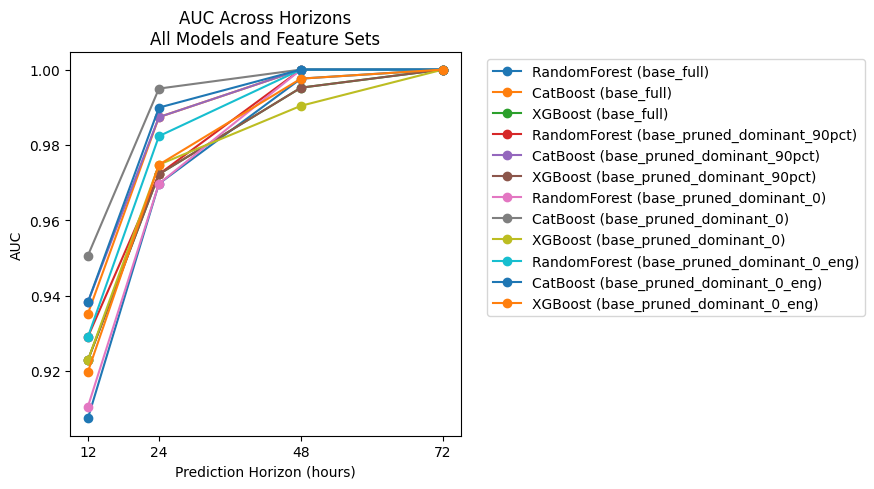

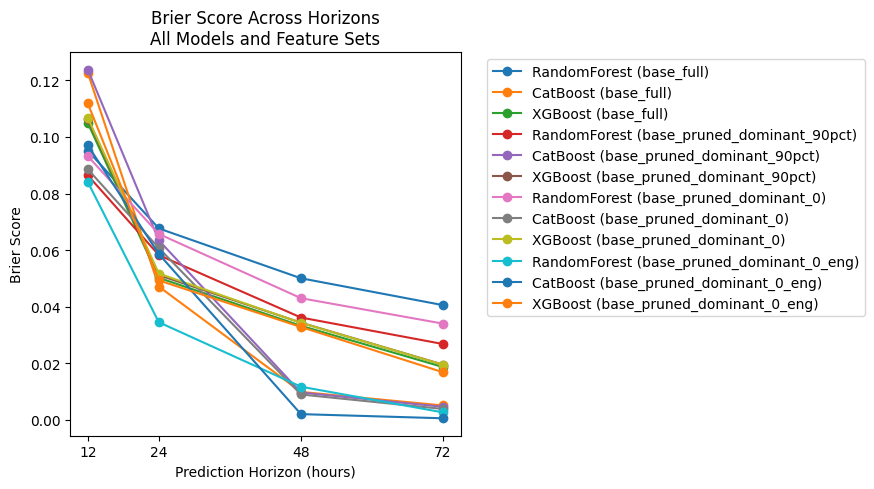

In [17]:
# Plot all model + feature-set lines together
# AUC
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for label in ordered_rows:
    df_part = model_comparison_df[
        model_comparison_df["model_feature_set"] == label
    ].sort_values("horizon")

    plt.plot(
        df_part["horizon"],
        df_part["AUC"],
        marker="o",
        label=label
    )

plt.xlabel("Prediction Horizon (hours)")
plt.ylabel("AUC")
plt.title("AUC Across Horizons\nAll Models and Feature Sets")
plt.xticks(ordered_horizons)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Brier
plt.figure(figsize=(9, 5))

for label in ordered_rows:
    df_part = model_comparison_df[
        model_comparison_df["model_feature_set"] == label
    ].sort_values("horizon")

    plt.plot(
        df_part["horizon"],
        df_part["Brier"],
        marker="o",
        label=label
    )

plt.xlabel("Prediction Horizon (hours)")
plt.ylabel("Brier Score")
plt.title("Brier Score Across Horizons\nAll Models and Feature Sets")
plt.xticks(ordered_horizons)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 8. Feature Importance Analysis

Using the best model: **CatBoost (base_pruned_dominant_0)**

In [18]:
# Best model from comparison
BEST_FS = "base_pruned_dominant_0"
BEST_MODEL = "CatBoost"
X_best = pruning_feature_sets[BEST_FS]
best_models = all_trained_models[(BEST_FS, BEST_MODEL)]
feat_cols = X_best.columns

# Check if engineered features did better
if ("base_pruned_dominant_0_eng", "CatBoost") in all_trained_models:
    eng_auc = model_comparison_df[
        (model_comparison_df["model"] == "CatBoost") &
        (model_comparison_df["feature_set"] == "base_pruned_dominant_0_eng") &
        (model_comparison_df["horizon"] == 48)
    ]["AUC"].values
    base_auc = model_comparison_df[
        (model_comparison_df["model"] == "CatBoost") &
        (model_comparison_df["feature_set"] == "base_pruned_dominant_0") &
        (model_comparison_df["horizon"] == 48)
    ]["AUC"].values
    if len(eng_auc) and len(base_auc) and eng_auc[0] >= base_auc[0]:
        BEST_FS = "base_pruned_dominant_0_eng"
        X_best = pruning_feature_sets[BEST_FS]
        best_models = all_trained_models[(BEST_FS, BEST_MODEL)]
        feat_cols = X_best.columns
        print(f"Engineered features are better! AUC: {eng_auc[0]:.4f} vs {base_auc[0]:.4f}")
    else:
        print(f"Base features are better. Using {BEST_FS}")

print(f"Best feature set: {BEST_FS} ({len(feat_cols)} features)")

# Feature importance for 48h
model_48 = best_models[48]
fi_48 = pd.DataFrame({
    "feature": feat_cols,
    "importance": model_48.get_feature_importance()
}).sort_values("importance", ascending=False)

print("\nTop 15 features (48h):")
display(fi_48.head(15))

Engineered features are better! AUC: 1.0000 vs 1.0000
Best feature set: base_pruned_dominant_0_eng (36 features)

Top 15 features (48h):


,feature,importance
30,dist_close,59.195234
29,log_dist_min,14.331765
18,dist_min_ci_0_5h,12.768103
32,dist_x_area,1.691587
33,dist_per_area,1.503855
7,log1p_area_first,1.460927
34,log_dist_x_log_area,0.965184
27,event_start_dayofweek,0.865174
26,event_start_hour,0.829677
28,event_start_month,0.827592


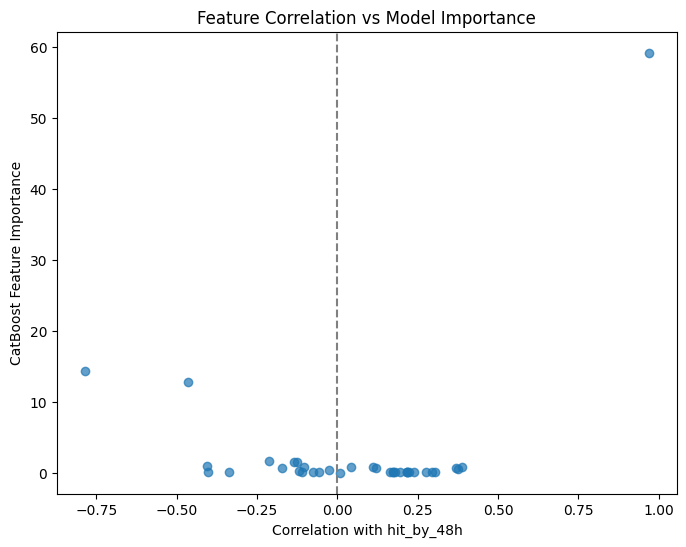

In [19]:
try:
    corr_48 = X_best.corrwith(train["hit_by_48h"])
    corr_importance_df = pd.DataFrame({
        "feature": feat_cols,
        "correlation": corr_48.values,
        "importance": fi_48.set_index("feature").loc[feat_cols]["importance"].values
    })
    plt.figure(figsize=(8, 6))
    plt.scatter(corr_importance_df["correlation"], corr_importance_df["importance"], alpha=0.7)
    plt.axvline(0, linestyle="--", color="gray")
    plt.xlabel("Correlation with hit_by_48h")
    plt.ylabel("CatBoost Feature Importance")
    plt.title("Feature Correlation vs Model Importance")
    plt.show()
except Exception as e:
    print(f"Correlation plot skipped: {e}")

In [20]:
# Feature importance across all horizons
all_fi = []
for h in HORIZONS:
    temp = pd.DataFrame({
        "feature": feat_cols,
        "importance": best_models[h].get_feature_importance(),
        "horizon": f"{h}h"
    })
    all_fi.append(temp)

all_fi_df = pd.concat(all_fi, ignore_index=True)

for h in HORIZONS:
    print(f"\nTop 10 features for hit_by_{h}h")
    display(
        all_fi_df[all_fi_df["horizon"] == f"{h}h"]
        .sort_values("importance", ascending=False)
        .head(10)
    )


Top 10 features for hit_by_12h


,feature,importance,horizon
30,dist_close,30.760645,12h
18,dist_min_ci_0_5h,15.817133,12h
29,log_dist_min,9.507551,12h
1,dt_first_last_0_5h,8.828933,12h
26,event_start_hour,6.954170,12h
33,dist_per_area,4.255117,12h
23,alignment_abs,3.884742,12h
32,dist_x_area,2.760525,12h
28,event_start_month,2.682896,12h
3,area_first_ha,2.647134,12h



Top 10 features for hit_by_24h


,feature,importance,horizon
66,dist_close,51.171552,24h
65,log_dist_min,15.461155,24h
54,dist_min_ci_0_5h,14.133690,24h
69,dist_per_area,2.638578,24h
68,dist_x_area,2.171834,24h
43,log1p_area_first,1.850041,24h
63,event_start_dayofweek,1.822991,24h
39,area_first_ha,1.601598,24h
62,event_start_hour,1.476414,24h
36,num_perimeters_0_5h,1.112665,24h



Top 10 features for hit_by_48h


,feature,importance,horizon
102,dist_close,59.195234,48h
101,log_dist_min,14.331765,48h
90,dist_min_ci_0_5h,12.768103,48h
104,dist_x_area,1.691587,48h
105,dist_per_area,1.503855,48h
79,log1p_area_first,1.460927,48h
106,log_dist_x_log_area,0.965184,48h
99,event_start_dayofweek,0.865174,48h
98,event_start_hour,0.829677,48h
100,event_start_month,0.827592,48h



Top 10 features for hit_by_72h


,feature,importance,horizon
138,dist_close,61.585823,72h
137,log_dist_min,15.618054,72h
126,dist_min_ci_0_5h,15.400046,72h
130,alignment_cos,0.622733,72h
115,log1p_area_first,0.563869,72h
135,event_start_dayofweek,0.562351,72h
140,dist_x_area,0.541808,72h
142,log_dist_x_log_area,0.443618,72h
108,num_perimeters_0_5h,0.441633,72h
134,event_start_hour,0.427515,72h


## 9. Error Analysis (Validation Set, 48h)

In [21]:
try:
    h = 48
    target_col = f"hit_by_{h}h"
    y_valid = train.loc[idx_valid, target_col].copy()

    X_valid_best = X_best.loc[idx_valid]
    prob_valid_48 = best_models[h].predict_proba(X_valid_best)[:, 1]
    pred_valid_48 = (prob_valid_48 >= 0.5).astype(int)

    valid_analysis = X_valid_best.copy()
    valid_analysis["y_true"] = y_valid.values
    valid_analysis["prob"] = prob_valid_48
    valid_analysis["y_pred"] = pred_valid_48
    valid_analysis["error"] = (valid_analysis["y_true"] != valid_analysis["y_pred"]).astype(int)
    print(f"Validation analysis built: {valid_analysis.shape}")
except Exception as e:
    print(f"Error analysis skipped: {e}")
    valid_analysis = None

Validation analysis built: (45, 40)


In [22]:
if valid_analysis is not None:
    tp = ((valid_analysis["y_true"] == 1) & (valid_analysis["y_pred"] == 1)).sum()
    tn = ((valid_analysis["y_true"] == 0) & (valid_analysis["y_pred"] == 0)).sum()
    fp = ((valid_analysis["y_true"] == 0) & (valid_analysis["y_pred"] == 1)).sum()
    fn = ((valid_analysis["y_true"] == 1) & (valid_analysis["y_pred"] == 0)).sum()
    print(f"TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    print(f"Accuracy: {(tp + tn) / len(valid_analysis):.3f}")
else:
    print("Skipped (no valid_analysis)")

TP=13  TN=32  FP=0  FN=0
Accuracy: 1.000


In [23]:
if valid_analysis is not None:
    false_positives = valid_analysis[
        (valid_analysis["y_true"] == 0) & (valid_analysis["y_pred"] == 1)
    ].sort_values("prob", ascending=False)

    false_negatives = valid_analysis[
        (valid_analysis["y_true"] == 1) & (valid_analysis["y_pred"] == 0)
    ].sort_values("prob", ascending=True)

    print(f"False positives: {len(false_positives)}")
    display(false_positives.head(10))
    print(f"\nFalse negatives: {len(false_negatives)}")
    display(false_negatives.head(10))
else:
    print("Skipped")

False positives: 0


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_close,dist_very_close,dist_x_area,dist_per_area,log_dist_x_log_area,dist_x_slope,y_true,prob,y_pred,error



False negatives: 0


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,...,dist_close,dist_very_close,dist_x_area,dist_per_area,log_dist_x_log_area,dist_x_slope,y_true,prob,y_pred,error


In [24]:
if valid_analysis is not None:
    error_summary = valid_analysis.groupby("error")[feat_cols].mean().T
    if error_summary.shape[1] == 2:
        error_summary.columns = ["Correct_avg", "Error_avg"]
        error_summary["abs_diff"] = (error_summary["Correct_avg"] - error_summary["Error_avg"]).abs()
        display(error_summary.sort_values("abs_diff", ascending=False).head(20))
    else:
        print("No misclassified samples - model got all validation rows correct.")
else:
    print("Skipped")

No misclassified samples - model got all validation rows correct.


,prob_bucket,n,actual_rate,predicted_avg,error_rate
0,"(-0.001, 0.1]",31,0.0,0.003176,0.0
1,"(0.1, 0.2]",0,NaN,NaN,NaN
2,"(0.2, 0.3]",1,0.0,0.297532,0.0
3,"(0.3, 0.4]",0,NaN,NaN,NaN
4,"(0.4, 0.5]",0,NaN,NaN,NaN
5,"(0.5, 0.6]",0,NaN,NaN,NaN
6,"(0.6, 0.7]",0,NaN,NaN,NaN
7,"(0.7, 0.8]",0,NaN,NaN,NaN
8,"(0.8, 0.9]",0,NaN,NaN,NaN
9,"(0.9, 1.0]",13,1.0,0.997592,0.0


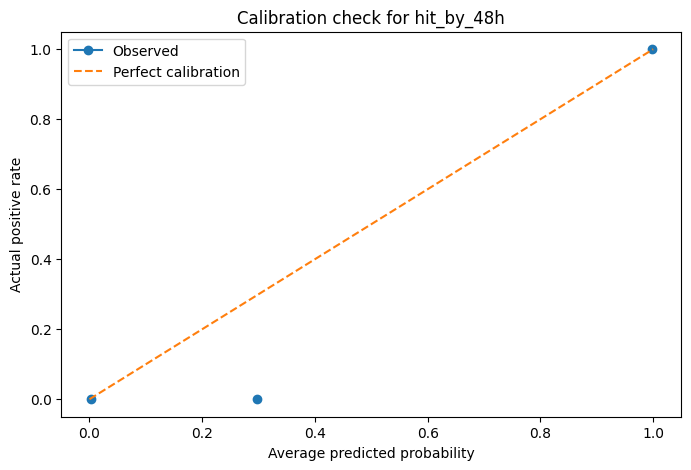

In [25]:
if valid_analysis is not None:
    valid_analysis["prob_bucket"] = pd.cut(
        valid_analysis["prob"], bins=np.linspace(0, 1, 11), include_lowest=True
    )
    bucket_summary = valid_analysis.groupby("prob_bucket", observed=False).agg(
        n=("y_true", "size"),
        actual_rate=("y_true", "mean"),
        predicted_avg=("prob", "mean"),
        error_rate=("error", "mean")
    ).reset_index()
    display(bucket_summary)

    plt.figure(figsize=(8, 5))
    plt.plot(bucket_summary["predicted_avg"], bucket_summary["actual_rate"], marker="o", label="Observed")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.xlabel("Average predicted probability")
    plt.ylabel("Actual positive rate")
    plt.title("Calibration check for hit_by_48h")
    plt.legend()
    plt.show()
else:
    print("Skipped")

<cell_type>markdown</cell_type>## 10. Final Predictions & Submission

Use **cross-validated ensemble** (CatBoost + RandomForest) trained on split data for robust predictions.

In [26]:
# --- Cross-validated predictions with ensemble ---

# Use engineered features
X_final = X_eng.copy()
X_test_final = add_engineered_features(
    test[X_base_pruned_dominant_0.columns].copy()
)
feat_cols_final = X_final.columns

# CV settings
N_SPLITS = 5
N_REPEATS = 3
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

# Ensemble weights (CatBoost dominant based on comparison)
ENSEMBLE = {
    "CatBoost": (cb_model_factory, 0.6),
    "RandomForest": (rf_model_factory, 0.25),
    "XGBoost": (xgb_model_factory, 0.15),
}

test_preds = {h: np.zeros(len(test)) for h in HORIZONS}
oof_scores = {h: [] for h in HORIZONS}

for h in HORIZONS:
    target_col = f"hit_by_{h}h"
    y = train[target_col]
    oof_preds = np.zeros(len(train))
    oof_counts = np.zeros(len(train))

    for fold_idx, (tr_idx, va_idx) in enumerate(rskf.split(X_final, y)):
        X_tr = X_final.iloc[tr_idx]
        X_va = X_final.iloc[va_idx]
        y_tr = y.iloc[tr_idx]
        y_va = y.iloc[va_idx]

        fold_test_pred = np.zeros(len(test))

        for model_name, (factory, weight) in ENSEMBLE.items():
            model = factory()
            model.fit(X_tr, y_tr)

            # OOF predictions (for scoring)
            oof_preds[va_idx] += model.predict_proba(X_va)[:, 1] * weight
            # Test predictions (averaged across folds)
            fold_test_pred += model.predict_proba(X_test_final)[:, 1] * weight

        oof_counts[va_idx] += 1
        test_preds[h] += fold_test_pred / (N_SPLITS * N_REPEATS)

    # Average OOF where each sample was in validation
    oof_preds /= oof_counts
    auc = roc_auc_score(y, oof_preds)
    brier = brier_score_loss(y, oof_preds)
    oof_scores[h] = {"AUC": auc, "Brier": brier}
    print(f"Horizon {h}h - CV AUC: {auc:.4f}, CV Brier: {brier:.4f}")

prob_12h = test_preds[12]
prob_24h = test_preds[24]
prob_48h = test_preds[48]
prob_72h = test_preds[72]

print("\nExample predictions (first 5, 48h):", prob_48h[:5])

Horizon 12h - CV AUC: 0.9683, CV Brier: 0.0640
Horizon 24h - CV AUC: 0.9879, CV Brier: 0.0307
Horizon 48h - CV AUC: 0.9987, CV Brier: 0.0114
Horizon 72h - CV AUC: 1.0000, CV Brier: 0.0005

Example predictions (first 5, 48h): [0.00539098 0.985711   0.00536369 0.98494145 0.03660325]


In [27]:
# Enforce monotonicity: P(12h) <= P(24h) <= P(48h) <= P(72h)
prob_12h_fixed = prob_12h
prob_24h_fixed = np.maximum(prob_24h, prob_12h_fixed)
prob_48h_fixed = np.maximum(prob_48h, prob_24h_fixed)
prob_72h_fixed = np.maximum(prob_72h, prob_48h_fixed)

print("Monotonicity check (all should be True):")
print("  12h <= 24h:", np.all(prob_12h_fixed <= prob_24h_fixed))
print("  24h <= 48h:", np.all(prob_24h_fixed <= prob_48h_fixed))
print("  48h <= 72h:", np.all(prob_48h_fixed <= prob_72h_fixed))

Monotonicity check (all should be True):
  12h <= 24h: True
  24h <= 48h: True
  48h <= 72h: True


In [28]:
# Build and save submission
submission = pd.DataFrame({
    "event_id": test["event_id"],
    "prob_12h": prob_12h_fixed,
    "prob_24h": prob_24h_fixed,
    "prob_48h": prob_48h_fixed,
    "prob_72h": prob_72h_fixed,
})

print(submission.head())
print(f"\nMissing values: {submission.isna().any().any()}")

submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Saved: /kaggle/working/submission.csv")

   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.003775  0.003840  0.005391  0.007061
1  13353600  0.458667  0.983731  0.985711  0.986075
2  13942327  0.005396  0.005396  0.005396  0.006919
3  16112781  0.807362  0.974631  0.984941  0.985644
4  17132808  0.044002  0.044002  0.044002  0.044002

Missing values: False
Saved: /kaggle/working/submission.csv
